# Use `Backtest_by_County_wsize4_atleast_2`

In [1]:
import copy
import collections
import functools
import glob
import pickle
import scipy
import sklearn
import warnings

warnings.filterwarnings('ignore')

import itertools
import graphviz as gr
import numpy as np
import os
import pandas as pd
import pyfinance
import statsmodels.formula.api as smf
import statsmodels.api as sm


from matplotlib import style
from matplotlib import pyplot as plt
from pprint import pprint
from scipy import stats, special
from sklearn import datasets, mixture
from sklearn.metrics import confusion_matrix, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection._split import TimeSeriesSplit, _BaseKFold, indexable, _num_samples

from sklearn.utils import indexable
from sklearn.utils.validation import _num_samples, _deprecate_positional_args

from statsmodels.regression.rolling import RollingOLS
from tqdm import tqdm

from urllib.request import urlopen
import json
with urlopen('https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json') as response:
    counties = json.load(response)

import plotly.express as px
import plotly.figure_factory as ff

%matplotlib inline

style.use("fivethirtyeight")
pd.set_option("display.max_columns", 6)

np.random.seed(0)
pd.set_option('display.max_columns', None)

In [2]:
OVERWRITE = False

DATA_FOLDER = "../data"
FIGURES_FOLDER = "../figures"
OUTPUT_FOLDER = "../output"
CASE_COUNTS_FOLDER = os.path.join(DATA_FOLDER,"block_windowsize=2")
CASE_COUNTS_FNAMES_ARRAY = os.listdir(CASE_COUNTS_FOLDER)

COMPARISON_FOLDER = os.path.join(DATA_FOLDER,"confusion_state_forests_windowsize=2")
COMPARISON_FOLDER_FNAMES_ARRAY = os.listdir(COMPARISON_FOLDER)

BACKTEST_FOLDER = os.path.join(DATA_FOLDER,"Backtest_by_County_wsize4_atleast_2")
BACKTEST_FOLDER_FNAMES_ARRAY = os.listdir(BACKTEST_FOLDER)

In [3]:
sample_df = pd.read_csv(os.path.join(CASE_COUNTS_FOLDER,CASE_COUNTS_FNAMES_ARRAY[0]))
to_keep = ["fips", "datetime", "log_rolled_cases.x", "log_rolled_cases.y", "cutoff", "t0.lm", "r.lm", "shifted_log_rolled_cases"]
sample_df.columns


Index(['fips', 'State_FIPS_Code', 'county', 'state', 'datetime',
       'log_rolled_cases.x', 'shifted_time', 'log_rolled_cases.y', 'LAT',
       'LON',
       ...
       'totalTestsPeopleViralIncrease', 'totalTestsViral',
       'totalTestsViralIncrease', 'metrics.testPositivityRatio',
       'metrics.vaccinationsInitiatedRatio',
       'metrics.vaccinationsCompletedRatio', 'cutoff', 't0.lm', 'r.lm',
       'shifted_log_rolled_cases'],
      dtype='object', length=422)

### Analyze on `all_backtest_latest.csv`

In [4]:
all_backtest_fname = os.path.join(DATA_FOLDER,"all_backtest_latest.csv")
if (not os.path.isfile(all_backtest_fname) or OVERWRITE):
    print("{} not yet generated".format(all_backtest_fname))

    # Get the backtest fnames for all states
    BACKTEST_PATH_ARRAY = [os.path.join(BACKTEST_FOLDER,fname) for fname in BACKTEST_FOLDER_FNAMES_ARRAY]
    all_backtest_df_orig = pd.concat(map(pd.read_csv, BACKTEST_PATH_ARRAY))
    # Drop columns
    dropcols = ['D.r.lm', 'D.tau.hat', 'B.D.r.lm','B.D.tau.hat']
    dropcols += ['predicted.grf.future.0', "state"]
    #dropcols += ["D.r.slm","B.D.r.slm"]
    all_backtest_df = all_backtest_df_orig.drop(columns=dropcols,axis=1)
    # Rename tau.hat to r.grf
    renamecols = {"tau.hat":"r.grf", "predicted.grf.future.last":"predicted.grf"}
    all_backtest_df = all_backtest_df.rename(columns=renamecols)
    all_backtest_df.to_csv(all_backtest_fname, index=False)

else:
    print("Loading {}".format(all_backtest_fname))
    all_backtest_df = pd.read_csv(all_backtest_fname)

Loading ../data\all_backtest_latest.csv


In [5]:
all_backtest_df = all_backtest_df.dropna()
all_backtest_df.head(12)

,fips,county,r.lm,predicted.lm,date.y,days_from_start.y,log_rolled_cases.y,r.grf,tau.variance,tau.upr,tau.lwr,predicted.grf
0,10001,Kent,0.117783,2.328559,2020-03-29,68,3.113515,0.176861,0.000442,0.218052,0.135671,2.742107
1,10001,Kent,0.245122,3.465057,2020-03-30,69,3.198673,0.267104,0.000296,0.300849,0.233359,3.618927
2,10001,Kent,0.231802,3.603613,2020-03-31,70,3.323236,0.243225,0.000262,0.274974,0.211477,3.683579
3,10001,Kent,0.270290,4.143324,2020-04-01,71,3.457893,0.262750,0.000169,0.288199,0.237300,4.090540
4,10001,Kent,0.313658,4.760552,2020-04-02,72,3.590439,0.315730,0.000286,0.348858,0.282602,4.775060
5,10001,Kent,0.207639,4.226064,2020-04-03,73,3.761200,0.231685,0.000857,0.289074,0.174297,4.394387
6,10001,Kent,0.210565,4.457107,2020-04-04,74,3.941582,0.224016,0.000187,0.250800,0.197233,4.551269
7,10001,Kent,0.130362,4.026048,2020-04-05,75,4.139159,0.171116,0.000130,0.193431,0.148801,4.311327
8,10001,Kent,0.085158,3.794778,2020-04-06,76,4.430817,0.128080,0.000306,0.162357,0.093802,4.095231
9,10001,Kent,0.124563,4.195175,2020-04-07,77,4.675163,0.154928,0.000072,0.171528,0.138327,4.407730


In [6]:
lm_rmse = all_backtest_df.groupby(["days_from_start.y"]).apply(lambda x: mean_squared_error(x["predicted.lm"], x["log_rolled_cases.y"]) ** .5)
grf_rmse = all_backtest_df.groupby(["days_from_start.y"]).apply(lambda x: mean_squared_error(x["predicted.grf"], x["log_rolled_cases.y"]) ** .5)

(0.08, 1.0)

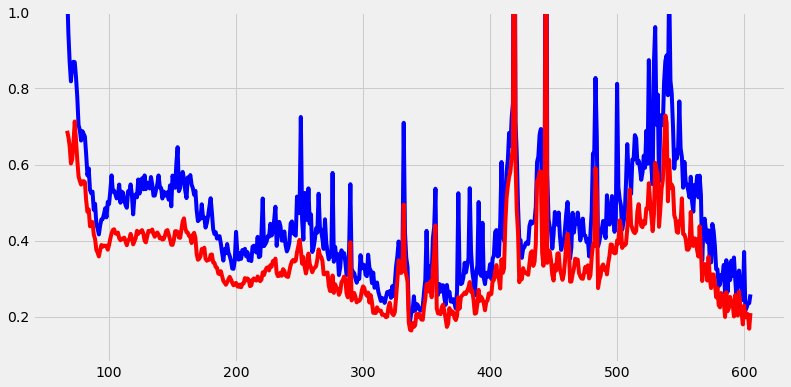

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(lm_rmse, color="blue", label="lm wsize=2")
ax.plot(grf_rmse, color = "red", label="grf")
plt.ylim([0.08,1.0])
#plt.xlim([365,len(grf_rmse)])

In [8]:
historical_data = all_backtest_df[["fips","days_from_start.y","log_rolled_cases.y"]]
historical_data['date_delta'] = (historical_data['days_from_start.y'] - historical_data['days_from_start.y'].min()) 

historical_data.head()

,fips,days_from_start.y,log_rolled_cases.y,date_delta
0,10001,68,3.113515,1
1,10001,69,3.198673,2
2,10001,70,3.323236,3
3,10001,71,3.457893,4
4,10001,72,3.590439,5


In [9]:
model_dict_fname = os.path.join(DATA_FOLDER,"model_dict.p")
OVERWRITE = False
if (not os.path.isfile(model_dict_fname)) or OVERWRITE:
    print("Generating model parameters and writing to {}".format(model_dict_fname))
    X = historical_data["date_delta"]
    X = sm.add_constant(X)
    y = historical_data["days_from_start.y"]
    model_dict = collections.defaultdict(dict)
    for wsize in range(2, 15):
        all_backtest_df["lm.pred.{}".format(wsize)] = np.nan
        for fips in tqdm(historical_data["fips"].unique()):
            df_mask = historical_data["fips"]==fips
            df = historical_data[df_mask]
            if df.shape[0] < wsize + 1:
                continue
            endog = df[['log_rolled_cases.y']].values
            exog = (df['days_from_start.y'] - df['days_from_start.y'].min()).values
            exog = sm.add_constant(exog)
            model = RollingOLS(endog=endog, exog=exog, window=wsize)
            results = model.fit()
            model_dict[wsize][fips] = results.params
            ypred = results.params[:,0] + results.params[:,1]*np.array([7 + i for i in range(len(endog))])
            all_backtest_df.loc[df_mask,'lm.pred.{}'.format(wsize)] = ypred
    with open(model_dict_fname, "wb+") as f:
        pickle.dump(model_dict,f)
    all_backtest_df.to_csv(all_backtest_fname, index=False)
else:
    print("Loading existing {}".format(model_dict_fname))
    with open(model_dict_fname, "rb+") as f:
        model_dict = pickle.load(f)
    all_backtest_df = pd.read_csv(all_backtest_fname)

Loading existing ../data\model_dict.p


In [10]:
preds = all_backtest_df[["fips","days_from_start.y"]+list(all_backtest_df.columns[12:])]
preds["days_from_start.y"] += 7
all_backtest_df_old = all_backtest_df[all_backtest_df.columns[:12]]
all_backtest_df.columns

Index(['fips', 'county', 'r.lm', 'predicted.lm', 'date.y', 'days_from_start.y',
       'log_rolled_cases.y', 'r.grf', 'tau.variance', 'tau.upr', 'tau.lwr',
       'predicted.grf'],
      dtype='object')

In [11]:
adjusted = pd.merge(left=all_backtest_df_old, right=preds.shift(7), left_on=["fips","days_from_start.y"], right_on=["fips","days_from_start.y"], how="left")
adjusted = adjusted.dropna()

###  `augmented_us-counties_latest.csv`

In [12]:
augmented_fname = os.path.join(DATA_FOLDER,"augmented_us-counties_latest.csv")
county_historical_data_fname = os.path.join(DATA_FOLDER,"county_historical_data.csv")
if (not os.path.isfile(county_historical_data_fname) or OVERWRITE):
    augmented = pd.read_csv(augmented_fname)
    cols_to_keep = ["fips","date","days_from_start","county","state","log_rolled_cases"]
    county_historical_data = augmented.sort_values(["fips","date"])
    county_historical_data = county_historical_data[county_historical_data["rolled_cases"] >= 20]
    county_historical_data["log_rolled_cases"] = np.log(county_historical_data["rolled_cases"])
    county_historical_data = county_historical_data[cols_to_keep]

    # Get rid of records with less than 2 entries
    v = county_historical_data[['fips']]
    county_historical_data[v.replace(v.stack().value_counts()).gt(2).all(1)]


    county_historical_data.to_csv(county_historical_data_fname, index=False)
else:
    county_historical_data = pd.read_csv(county_historical_data_fname)

In [13]:
model_dict_county_fname = os.path.join(DATA_FOLDER,"model_dict_county.p")
county_historical_data_rolling_fname = os.path.join(DATA_FOLDER,"county_historical_data_rolling.csv")
county_historical_data_rolling = county_historical_data.copy()
if (not os.path.isfile(model_dict_county_fname)) or OVERWRITE:
    print("Generating model parameters and writing to {}".format(model_dict_county_fname))
    model_dict_county = collections.defaultdict(dict)
    for wsize in range(2, 15):
        county_historical_data_rolling["lm.pred.{}".format(wsize)] = np.nan
        for fips in tqdm(county_historical_data_rolling["fips"].unique()):
            df_mask = county_historical_data_rolling["fips"]==fips
            df = county_historical_data_rolling[df_mask]
            if df.shape[0] < wsize + 1:
                continue
            endog = df[['log_rolled_cases']]
            exog = (df['days_from_start'] - df['days_from_start'].min())
            exog = sm.add_constant(exog)
            model = RollingOLS(endog=endog, exog=exog, window=wsize)
            results = model.fit(params_only=True)
            model_dict_county[wsize][fips] = results.params
            par = results.params.values
            ypred = endog.values.flatten() + par[:,1]*np.array([7 for i in range(len(endog))])
            county_historical_data_rolling.loc[df_mask,'lm.pred.{}'.format(wsize)] = ypred
            #break
    
    with open(model_dict_county_fname, "wb+") as f:
        pickle.dump(model_dict_county,f)
    county_historical_data_rolling.to_csv(county_historical_data_rolling_fname, index=False)
else:
    print("Loading existing {}".format(model_dict_county_fname))
    with open(model_dict_county_fname, "rb+") as f:
        model_dict_county = pickle.load(f)
    county_historical_data_rolling = pd.read_csv(county_historical_data_rolling_fname)

Loading existing ../data\model_dict_county.p


In [14]:
county_historical_data_rolling.loc[county_historical_data_rolling["fips"]==10001]

,fips,date,days_from_start,county,state,log_rolled_cases,lm.pred.2,lm.pred.3,lm.pred.4,lm.pred.5,lm.pred.6,lm.pred.7,lm.pred.8,lm.pred.9,lm.pred.10,lm.pred.11,lm.pred.12,lm.pred.13,lm.pred.14
127379,10001,2020-03-29,68,Kent,Delaware,3.113515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
127380,10001,2020-03-30,69,Kent,Delaware,3.198673,3.794778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
127381,10001,2020-03-31,70,Kent,Delaware,3.323236,4.195175,4.057258,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
127382,10001,2020-04-01,71,Kent,Delaware,3.457893,4.400491,4.365161,4.268279,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
127383,10001,2020-04-02,72,Kent,Delaware,3.590439,4.518266,4.525652,4.507408,4.439587,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127912,10001,2021-09-13,601,Kent,Delaware,7.607754,7.650466,7.655439,7.660213,7.662995,7.656539,7.646703,7.641524,7.640944,7.648139,7.661040,7.673845,7.685806,7.693808
127913,10001,2021-09-14,602,Kent,Delaware,7.608002,7.609740,7.630227,7.641406,7.649349,7.654511,7.651852,7.645298,7.641486,7.641063,7.647081,7.658198,7.669615,7.680578
127914,10001,2021-09-15,603,Kent,Delaware,7.611224,7.633777,7.623369,7.631499,7.639601,7.646711,7.652047,7.651243,7.646766,7.643966,7.643737,7.648913,7.658640,7.668906
127915,10001,2021-09-16,604,Kent,Delaware,7.619724,7.679226,7.660751,7.647117,7.647454,7.651112,7.655691,7.659735,7.659254,7.655680,7.653278,7.652959,7.657293,7.665739


In [15]:
all_backtest_df_old

,fips,county,r.lm,predicted.lm,date.y,days_from_start.y,log_rolled_cases.y,r.grf,tau.variance,tau.upr,tau.lwr,predicted.grf
0,10001,Kent,0.117783,2.328559,2020-03-29,68,3.113515,0.176861,0.000442,0.218052,0.135671,2.742107
1,10001,Kent,0.245122,3.465057,2020-03-30,69,3.198673,0.267104,0.000296,0.300849,0.233359,3.618927
2,10001,Kent,0.231802,3.603613,2020-03-31,70,3.323236,0.243225,0.000262,0.274974,0.211477,3.683579
3,10001,Kent,0.270290,4.143324,2020-04-01,71,3.457893,0.262750,0.000169,0.288199,0.237300,4.090540
4,10001,Kent,0.313658,4.760552,2020-04-02,72,3.590439,0.315730,0.000286,0.348858,0.282602,4.775060
...,...,...,...,...,...,...,...,...,...,...,...,...
1526338,99999,New York City,-0.009074,10.493593,2021-09-20,608,NaN,-0.006798,0.000006,-0.002194,-0.011401,10.509531
1526339,99999,New York City,-0.005810,10.510633,2021-09-21,609,NaN,-0.005096,0.000006,-0.000426,-0.009767,10.515629
1526340,99999,New York City,-0.015402,10.428091,2021-09-22,610,NaN,-0.011081,0.000015,-0.003441,-0.018721,10.458337
1526341,99999,New York City,0.010478,10.619727,2021-09-23,611,NaN,0.008323,0.000002,0.010953,0.005692,10.604640


In [16]:
county_historical_data_rolling.columns

Index(['fips', 'date', 'days_from_start', 'county', 'state',
       'log_rolled_cases', 'lm.pred.2', 'lm.pred.3', 'lm.pred.4', 'lm.pred.5',
       'lm.pred.6', 'lm.pred.7', 'lm.pred.8', 'lm.pred.9', 'lm.pred.10',
       'lm.pred.11', 'lm.pred.12', 'lm.pred.13', 'lm.pred.14'],
      dtype='object')

In [17]:
grf_historical = all_backtest_df_old[["fips","days_from_start.y","predicted.grf"]]
grf_historical = grf_historical.rename(columns={"days_from_start.y":"days_from_start"})
preds = county_historical_data_rolling[["fips","days_from_start"]+list(county_historical_data_rolling.columns[6:])]
preds["days_from_start"] += 7
county_historical_data_rolling_old = county_historical_data_rolling[county_historical_data_rolling.columns[:6]]
adjusted = pd.merge(left=county_historical_data_rolling_old, right=preds.shift(7), left_on=["fips","days_from_start"], right_on=["fips","days_from_start"], how="left")
adjusted = pd.merge(left=grf_historical, right=adjusted, left_on=["fips","days_from_start"], right_on=["fips","days_from_start"], how="left")
adjusted = adjusted.dropna()

In [18]:
adjusted

,fips,days_from_start,predicted.grf,date,county,state,log_rolled_cases,lm.pred.2,lm.pred.3,lm.pred.4,lm.pred.5,lm.pred.6,lm.pred.7,lm.pred.8,lm.pred.9,lm.pred.10,lm.pred.11,lm.pred.12,lm.pred.13,lm.pred.14
20,10001,88,6.233389,2020-04-18,Kent,Delaware,5.881929,6.274697,6.305973,6.460198,6.657827,6.779492,6.894292,6.933171,6.933535,6.915480,6.879093,6.837612,6.794018,6.743927
21,10001,89,6.066028,2020-04-19,Kent,Delaware,5.920908,6.051755,6.203723,6.283276,6.420656,6.596258,6.723148,6.842956,6.900525,6.921485,6.921946,6.902623,6.875277,6.843273
22,10001,90,6.082748,2020-04-20,Kent,Delaware,5.964864,6.061046,6.092416,6.196145,6.275717,6.396586,6.552313,6.676777,6.796304,6.864985,6.900380,6.915099,6.909804,6.894752
23,10001,91,6.204923,2020-04-21,Kent,Delaware,6.006969,6.251632,6.199764,6.197839,6.260801,6.323979,6.424278,6.558545,6.674240,6.788287,6.861333,6.905206,6.929540,6.934606
24,10001,92,6.200526,2020-04-22,Kent,Delaware,6.050912,6.217303,6.270319,6.260405,6.262809,6.309705,6.362789,6.448108,6.565097,6.671602,6.779032,6.853294,6.902291,6.933330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1526331,99999,601,10.590581,2021-09-13,New York City,New York,10.557114,10.552786,10.503129,10.484691,10.504834,10.534865,10.564571,10.586209,10.599192,10.606162,10.613438,10.620428,10.626583,10.631276
1526332,99999,602,10.543993,2021-09-14,New York City,New York,10.551304,10.500115,10.518746,10.496403,10.481217,10.492194,10.514025,10.538337,10.557812,10.570795,10.578768,10.586769,10.594369,10.601123
1526333,99999,603,10.543655,2021-09-15,New York City,New York,10.535902,10.511698,10.499888,10.506343,10.491571,10.478665,10.484527,10.500536,10.520276,10.537306,10.549537,10.557702,10.565850,10.573621
1526334,99999,604,10.530825,2021-09-16,New York City,New York,10.546380,10.493169,10.496010,10.490061,10.493357,10.482845,10.472136,10.475291,10.487376,10.503584,10.518416,10.529695,10.537693,10.545709


## Fixed Window Sizes for All Counties

In [54]:
error_table = pd.DataFrame()
error_table["grf.rmse"]=adjusted.groupby(["days_from_start"]).apply(lambda x: mean_squared_error( (x["predicted.grf"]),  (x["log_rolled_cases"])) ** .5)
error_table["grf.mape"]=adjusted.groupby(["days_from_start"]).apply(lambda x: mean_absolute_percentage_error( (x["log_rolled_cases"]), (x["predicted.grf"])) )
error_table["grf.mae"]=adjusted.groupby(["days_from_start"]).apply(lambda x: mean_absolute_error( (x["predicted.grf"]),  (x["log_rolled_cases"])) )

for wsize in tqdm(range(2,14+1)):
    error_table["lm.rmse.{}".format(wsize)]=adjusted.groupby(["days_from_start"]).apply(lambda x: mean_squared_error((x["lm.pred.{}".format(wsize)]), (x["log_rolled_cases"])) ** .5)
    error_table["lm.mae.{}".format(wsize)]=adjusted.groupby(["days_from_start"]).apply(lambda x: mean_absolute_error((x["lm.pred.{}".format(wsize)]), (x["log_rolled_cases"])) )
    error_table["lm.mape.{}".format(wsize)]=adjusted.groupby(["days_from_start"]).apply(lambda x: mean_absolute_percentage_error((x["log_rolled_cases"]),(x["lm.pred.{}".format(wsize)])) )

error_table["date"] = sorted(adjusted["date"].unique())
#error_table = error_table.reset_index()
#error_table = error_table.set_index(adjusted["date.y"])
error_table.to_csv(os.path.join(DATA_FOLDER,"error_table_by_time.csv"))

100%|██████████████████████████████████████████████████████████████████████████████████| 13/13 [00:17<00:00,  1.36s/it]


In [20]:
adjusted.groupby("days_from_start").apply(lambda x: mean_squared_error(x["predicted.grf"], x["log_rolled_cases"]) ** .5)

days_from_start
67     0.375346
68     0.397996
69     0.720501
70     0.575897
71     0.561333
         ...   
601    0.174272
602    0.179915
603    0.187917
604    0.143790
605    0.189649
Length: 539, dtype: float64

In [21]:
error_table.columns
mape_columns = ["grf.mape"] + ["lm.mape.{}".format(wsize) for wsize in range(2,14+1)]
rmse_columns = ["grf.rmse"] + ["lm.rmse.{}".format(wsize) for wsize in range(2,14+1)]
date_column = ["days_from_start"]

In [57]:
error_table

,grf.rmse,grf.mape,grf.mae,lm.rmse.2,lm.mae.2,lm.mape.2,lm.rmse.3,lm.mae.3,lm.mape.3,lm.rmse.4,lm.mae.4,lm.mape.4,lm.rmse.5,lm.mae.5,lm.mape.5,lm.rmse.6,lm.mae.6,lm.mape.6,lm.rmse.7,lm.mae.7,lm.mape.7,lm.rmse.8,lm.mae.8,lm.mape.8,lm.rmse.9,lm.mae.9,lm.mape.9,lm.rmse.10,lm.mae.10,lm.mape.10,lm.rmse.11,lm.mae.11,lm.mape.11,lm.rmse.12,lm.mae.12,lm.mape.12,lm.rmse.13,lm.mae.13,lm.mape.13,lm.rmse.14,lm.mae.14,lm.mape.14,date
days_from_start,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
67,0.375346,0.049618,0.363440,0.187560,0.167314,0.022061,0.284258,0.252922,0.033431,0.332888,0.284337,0.037412,0.319949,0.256648,0.033668,0.288899,0.218000,0.028726,0.224727,0.172372,0.023782,0.216577,0.151537,0.022534,0.253768,0.208884,0.030140,0.312277,0.277818,0.039136,0.372843,0.340030,0.047356,0.423613,0.390429,0.053871,0.470148,0.434716,0.059777,0.500272,0.462635,0.063725,2020-03-28
68,0.397996,0.048525,0.370721,0.230322,0.190962,0.024388,0.243484,0.206519,0.026394,0.295962,0.222895,0.027372,0.344564,0.264010,0.032745,0.349023,0.258750,0.032052,0.330619,0.258021,0.032686,0.273025,0.235071,0.030839,0.238324,0.218734,0.029988,0.238218,0.209546,0.029922,0.268791,0.218738,0.031995,0.314490,0.277781,0.039676,0.357450,0.327378,0.046004,0.402777,0.371838,0.051830,2020-03-29
69,0.720501,0.069414,0.607894,0.664242,0.462440,0.049177,0.712989,0.494627,0.052694,0.790634,0.533133,0.056468,0.911373,0.598589,0.062763,0.998667,0.653985,0.068546,1.026359,0.675609,0.071155,0.993004,0.664372,0.070615,0.936851,0.632989,0.067930,0.889120,0.607330,0.066012,0.869650,0.596223,0.065561,0.866638,0.596368,0.066357,0.875141,0.605239,0.068101,0.878579,0.609833,0.069234,2020-03-30
70,0.575897,0.055688,0.477092,0.536802,0.402215,0.045992,0.631052,0.459754,0.051388,0.690651,0.504397,0.056074,0.757685,0.548713,0.060734,0.856686,0.604432,0.066307,0.940036,0.658407,0.072132,0.981829,0.691373,0.076064,0.976549,0.700372,0.077730,0.945979,0.690012,0.077283,0.914638,0.678322,0.076722,0.900534,0.675098,0.077013,0.893527,0.673122,0.077255,0.892783,0.672800,0.077533,2020-03-31
71,0.561333,0.054964,0.461931,0.479911,0.344680,0.039545,0.539047,0.385217,0.044524,0.648953,0.454425,0.052439,0.765483,0.549837,0.064029,0.870616,0.619212,0.071669,0.976325,0.675842,0.077248,1.044819,0.718567,0.081419,1.061146,0.741275,0.083847,1.042134,0.745073,0.084494,1.005136,0.731705,0.083181,0.970323,0.716395,0.081672,0.949208,0.705790,0.080547,0.932723,0.693813,0.079144,2020-04-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
601,0.174272,0.024508,0.133681,0.189878,0.143092,0.026304,0.198766,0.144770,0.026947,0.187216,0.135046,0.025247,0.181501,0.131631,0.024548,0.180808,0.131428,0.024626,0.185582,0.136510,0.025554,0.184336,0.137947,0.025783,0.184650,0.140076,0.026082,0.182933,0.139273,0.025871,0.183702,0.139239,0.025798,0.186619,0.141736,0.026204,0.192635,0.147004,0.027117,0.197295,0.152030,0.027954,2021-09-13
602,0.179915,0.023063,0.124526,0.194996,0.133403,0.024720,0.173685,0.124617,0.023241,0.182840,0.131497,0.024627,0.179649,0.127919,0.024024,0.174289,0.124304,0.023343,0.172616,0.123778,0.023297,0.175257,0.127048,0.023894,0.175746,0.129397,0.024264,0.177667,0.132526,0.024758,0.178396,0.133557,0.024866,0.180382,0.135093,0.025075,0.183514,0.138087,0.025556,0.189153,0.143252,0.026439,2021-09-14
603,0.187917,0.024451,0.131152,0.207095,0.141405,0.026288,0.154211,0.112023,0.020776,0.146901,0.104866,0.019541,0.152258,0.107560,0.020221,0.157581,0.110966,0.020897,0.158619,0.112471,0.021174,0.160845,0.114742,0.021587,0.165476,0.119749,0.022470,0.167867,0.123195,0.023040,0.171104,0.127173,0.023704,0.173168,0.129168,0.024003,0.175810,0.131240,0.024312,0.179220,0.134311,0.024814,2021-09-15


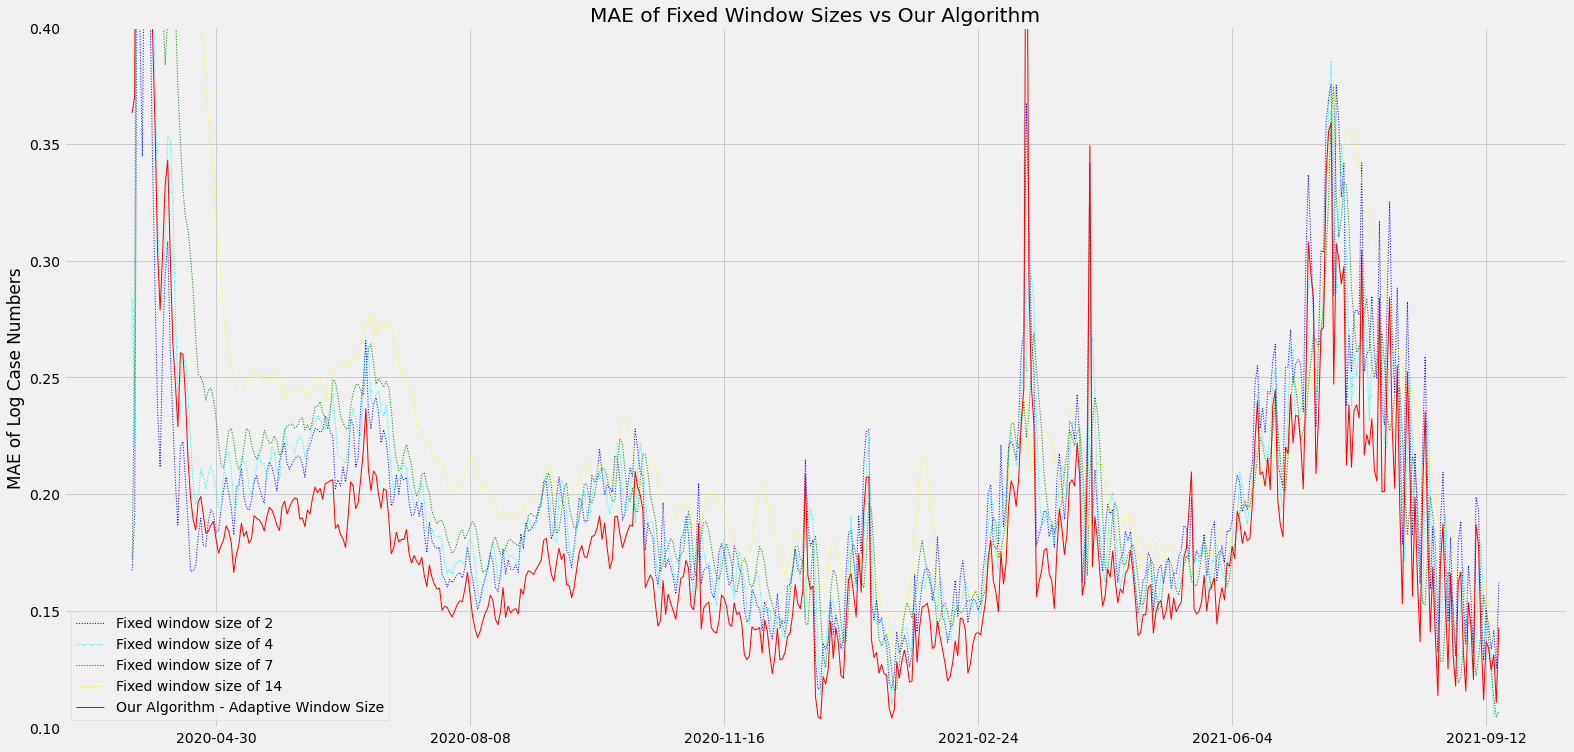

In [55]:
x_spacing = [100,200,300,400,500,600]
fig, ax = plt.subplots(figsize=(24, 12))
#for wsize in range(2,14+1,2):
wsizes = [2,4,7,14]
colors_lm = ["blue", "cyan", "green", "yellow"]
my_legend = ["Fixed window size of {}".format(wsize) for wsize in wsizes] + ["Our Algorithm - Adaptive Window Size"]
for i,wsize in enumerate(wsizes):
    ax.plot(error_table["lm.mae.{}".format(wsize)], linestyle='dotted', linewidth=1, color=colors_lm[i], label=my_legend[i])
ax.plot(error_table["grf.mae"], label=my_legend[-1], linewidth=1, color="red")
ax.legend()

plt.ylim([0.1,0.4])
plt.xticks(x_spacing,error_table["date"][x_spacing])
#plt.xlim([50,350])


plt.ylabel("MAE of Log Case Numbers")
plt.title("MAE of Fixed Window Sizes vs Our Algorithm")
plt.savefig(os.path.join(FIGURES_FOLDER,"lm_grf_mae.png"))

In [60]:
mae_medians = {}
mae_medians["grf"] = error_table["grf.mae"].median()
for i,wsize in enumerate(wsizes):
    mae_medians["{}".format(wsize)] = error_table["lm.mae.{}".format(wsize)].median()
mae_medians

{'grf': 0.16957942431221626,
 '2': 0.18673551794439572,
 '4': 0.18790830488694024,
 '7': 0.1911256992731933,
 '14': 0.20537566062235896}

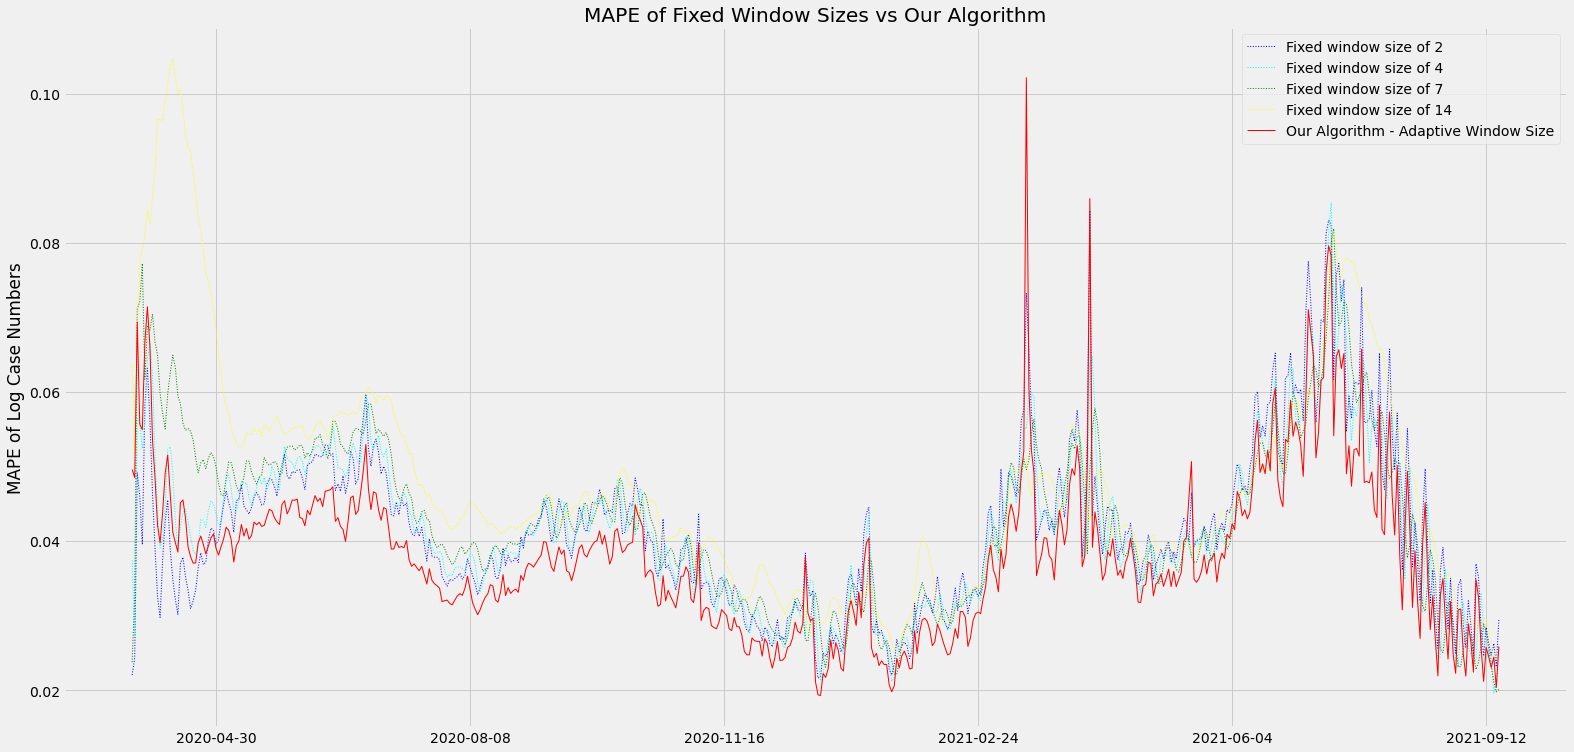

In [59]:
x_spacing = [100,200,300,400,500,600]
fig, ax = plt.subplots(figsize=(24, 12))
#for wsize in range(2,14+1,2):
wsizes = [2,4,7,14]
colors_lm = ["blue", "cyan", "green", "yellow"]
my_legend = ["Fixed window size of {}".format(wsize) for wsize in wsizes] + ["Our Algorithm - Adaptive Window Size"]
for i,wsize in enumerate(wsizes):
    ax.plot(error_table["lm.mape.{}".format(wsize)], linestyle='dotted', linewidth=1, color=colors_lm[i], label=my_legend[i])
ax.plot(error_table["grf.mape"], label=my_legend[-1], linewidth=1, color="red")
ax.legend()

#plt.ylim([0.1,0.4])
plt.xticks(x_spacing,error_table["date"][x_spacing])
#plt.xlim([50,350])


plt.ylabel("MAPE of Log Case Numbers")
plt.title("MAPE of Fixed Window Sizes vs Our Algorithm")
plt.savefig(os.path.join(FIGURES_FOLDER,"lm_grf_mape.png"))

In [61]:
mape_medians = {}
mape_medians["grf"] = error_table["grf.mape"].median()
for i,wsize in enumerate(wsizes):
    mape_medians["{}".format(wsize)] = error_table["lm.mape.{}".format(wsize)].median()
mape_medians

{'grf': 0.03764665794955454,
 '2': 0.040736983602950784,
 '4': 0.041164302574286854,
 '7': 0.04198262854372878,
 '14': 0.044376639765760624}

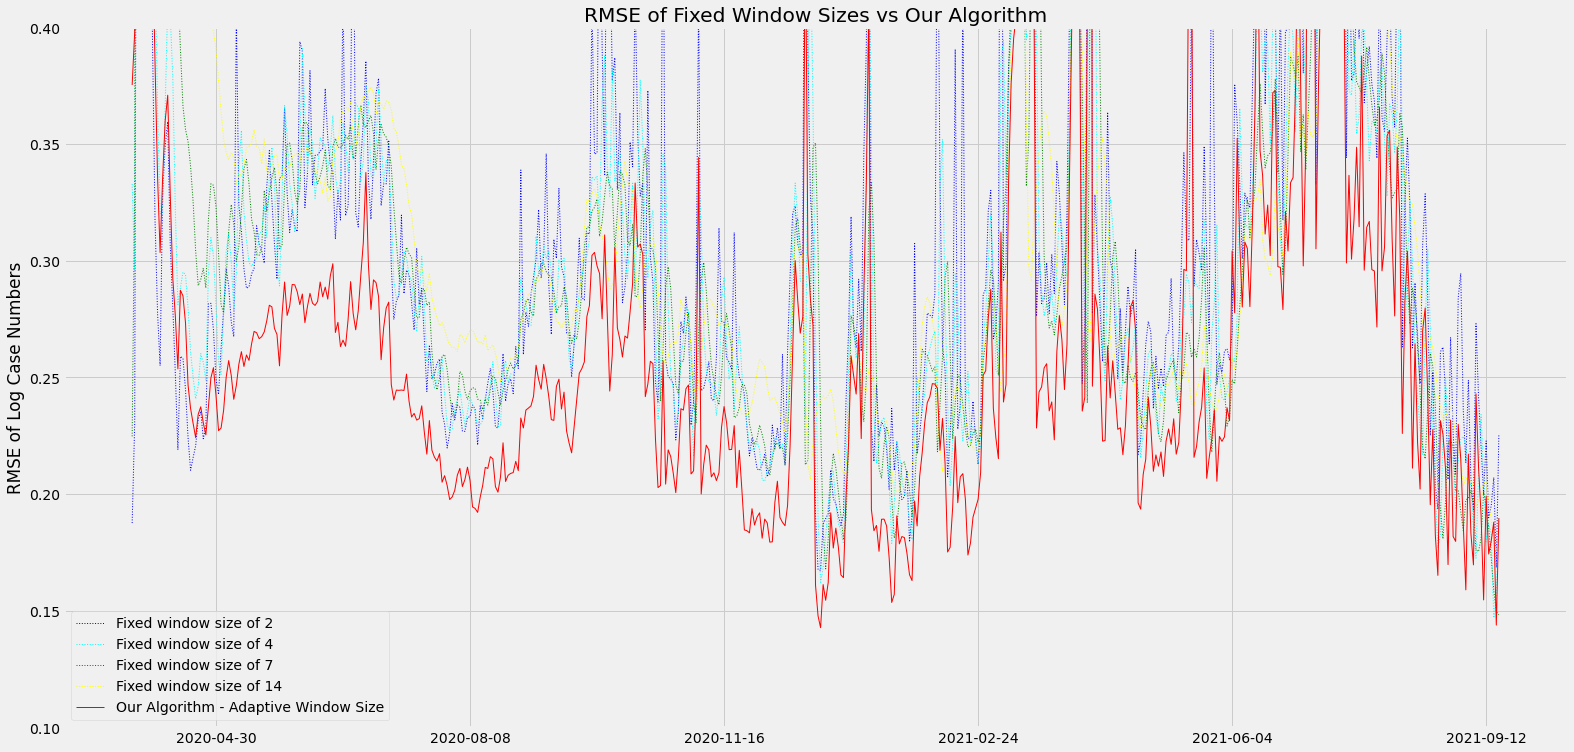

In [25]:
fig, ax = plt.subplots(figsize=(24, 12))
#for wsize in range(2,14+1,2):
colors_lm = ["blue", "cyan", "green", "yellow"]
my_legend = ["Fixed window size of {}".format(wsize) for wsize in wsizes] + ["Our Algorithm - Adaptive Window Size"]

for i,wsize in enumerate([2,4,7,14]):
    #print((i,wsize,colors_lm[i]))
    ax.plot(error_table["lm.rmse.{}".format(wsize)], linestyle='dotted', linewidth=1, color=colors_lm[i], label=my_legend[i])
ax.plot(error_table["grf.rmse"], label=my_legend[-1], color="red", linewidth=1)


leg = plt.legend()
plt.ylim([0.1,0.4])


#plt.setp(leg.get_lines(),linewidth=1)

plt.xticks(x_spacing,error_table["date"][x_spacing])
#plt.xlim([50,350])

plt.ylabel("RMSE of Log Case Numbers")
plt.title("RMSE of Fixed Window Sizes vs Our Algorithm")
plt.savefig(os.path.join(FIGURES_FOLDER,"lm_grf_rmse.png"))

In [26]:
rmse_medians = {}
rmse_medians["grf"] = error_table["grf.rmse"].median()
for i,wsize in enumerate(wsizes):
    rmse_medians["{}".format(wsize)] = error_table["lm.rmse.{}".format(wsize)].median()
rmse_medians

{'grf': 0.24457039886200085,
 '2': 0.28816946281247874,
 '4': 0.2884446199638821,
 '7': 0.28749370846398886,
 '14': 0.28449676721705996}

### Best Fixed Window Sizes for Each County 

In [27]:
fips_rmse_fname = os.path.join(DATA_FOLDER,"fips_rmse.p")
fips_mape_fname = os.path.join(DATA_FOLDER,"fips_mape.p")

if not (os.path.isfile(fips_rmse_fname) and  os.path.isfile(fips_mape_fname) ) or OVERWRITE:

    fips_rmse = {}
    fips_mape = {}
    for fips in tqdm(adjusted["fips"].unique()):
        df = adjusted[adjusted["fips"]==fips]
        best_rmse = np.inf
        best_mape = np.inf
        best_rmse_wsize = -999
        best_mape_wsize = -999
        for wsize in range(2,14+1):
            current_rmse = mean_squared_error(df["lm.pred.{}".format(wsize)], df["log_rolled_cases"]) ** .5
            if current_rmse < best_rmse:
                best_rmse = current_rmse
                best_rmse_wsize = wsize

            current_mape = mean_absolute_error(df["lm.pred.{}".format(wsize)], df["log_rolled_cases"])
            if current_mape < best_mape:
                best_mape = current_mape
                best_mape_wsize = wsize
        fips_mape[fips] = best_mape_wsize
        fips_rmse[fips] = best_rmse_wsize
    with open(fips_rmse_fname, "wb+") as f:
        pickle.dump(fips_rmse,f)
    with open(fips_mape_fname, "wb+") as f:
        pickle.dump(fips_mape,f)
else:
    with open(fips_rmse_fname, "rb+") as f:
        fips_rmse = pickle.load(f)
    with open(fips_mape_fname, "rb+") as f:
        fips_mape = pickle.load(f) 

In [28]:
# Compile Error Table using Best fixed window sizes of each fips
# Build new Dataframe
error_expost_fname = os.path.join(DATA_FOLDER,"error_expost.csv")
if (not os.path.isfile(error_expost_fname) or OVERWRITE):
    error_expost = pd.DataFrame()
    for fips in tqdm(adjusted["fips"].unique()):
        df_mask = (adjusted["fips"] == fips)
        df = adjusted[df_mask]
        new_df = df[["date","fips", "days_from_start","log_rolled_cases"]]
        new_df["lm.pred.mape.best"] = df["lm.pred.{}".format(fips_mape[fips])].values
        new_df["lm.pred.rmse.best"] = df["lm.pred.{}".format(fips_rmse[fips])].values
        error_expost = pd.concat([error_expost, new_df])
    error_expost.to_csv(error_expost_fname)
    #error_expost = error_expost.set_index(sorted(adjusted["days_from_start.y"].unique()))
else:
    error_expost = pd.read_csv(error_expost_fname)

In [76]:
# Generate by Day
error_expost_by_day = pd.DataFrame()

error_expost_by_day["lm.rmse"]=error_expost.groupby(["days_from_start"]).apply(lambda x: mean_squared_error(x["lm.pred.rmse.best"], x["log_rolled_cases"]) ** .5)
error_expost_by_day["lm.mape"]=error_expost.groupby(["days_from_start"]).apply(lambda x: mean_absolute_error(x["lm.pred.mape.best"], x["log_rolled_cases"]) )
error_expost_by_day["grf.mape"] = error_table["grf.mape"]
error_expost_by_day["grf.mae"] = error_table["grf.mae"]
error_expost_by_day["grf.rmse"] = error_table["grf.rmse"]
error_expost_by_day["date.y"] = error_table["date"]
error_expost_by_day.to_csv(os.path.join(DATA_FOLDER,"error_expost_by_day.csv"))

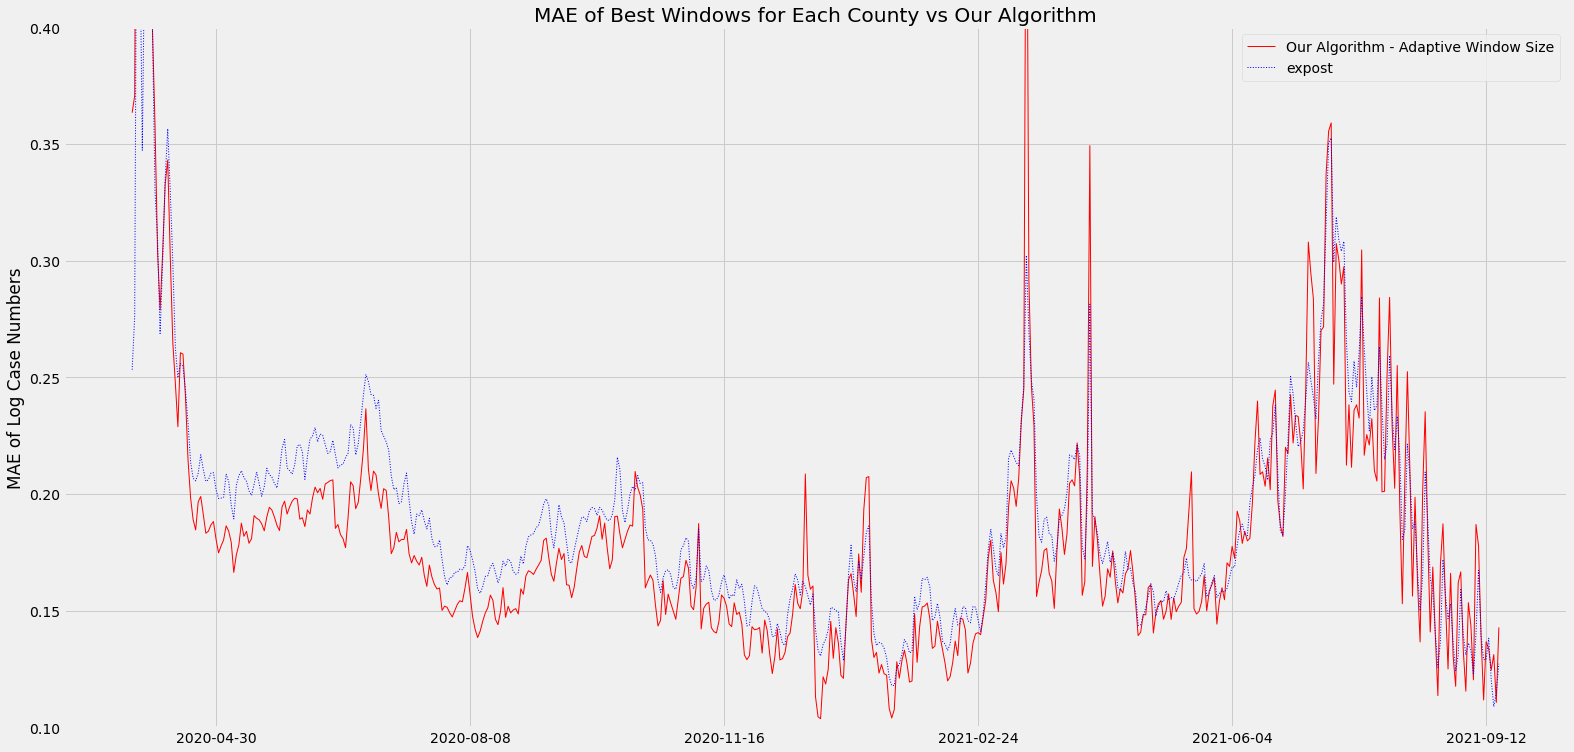

In [30]:
x_spacing = [100,200,300,400,500,600]
fig, ax = plt.subplots(figsize=(24, 12))
#for wsize in range(2,14+1,2):
my_legend = ["expost","Our Algorithm - Adaptive Window Size"]
ax.plot(error_expost_by_day["grf.mape"], linewidth=1, label=my_legend[1], color="red")
ax.plot(error_expost_by_day["lm.mape"], linewidth=1, linestyle='dotted', label=my_legend[0], color="blue")
ax.legend()
plt.xticks(x_spacing,error_expost_by_day["date.y"][x_spacing])
plt.ylim([0.1,0.4])
plt.ylabel("MAE of Log Case Numbers")
plt.title("MAE of Best Windows for Each County vs Our Algorithm")
plt.savefig(os.path.join(FIGURES_FOLDER,"best_windows_mae.png"))

In [31]:
expost_mae_medians = {}
expost_mae_medians["grf"] = error_expost_by_day["grf.mape"].median()
expost_mae_medians["lm"] = error_expost_by_day["lm.mape"].median()
expost_mae_medians

{'grf': 0.16957942431221626, 'lm': 0.18085917129139858}

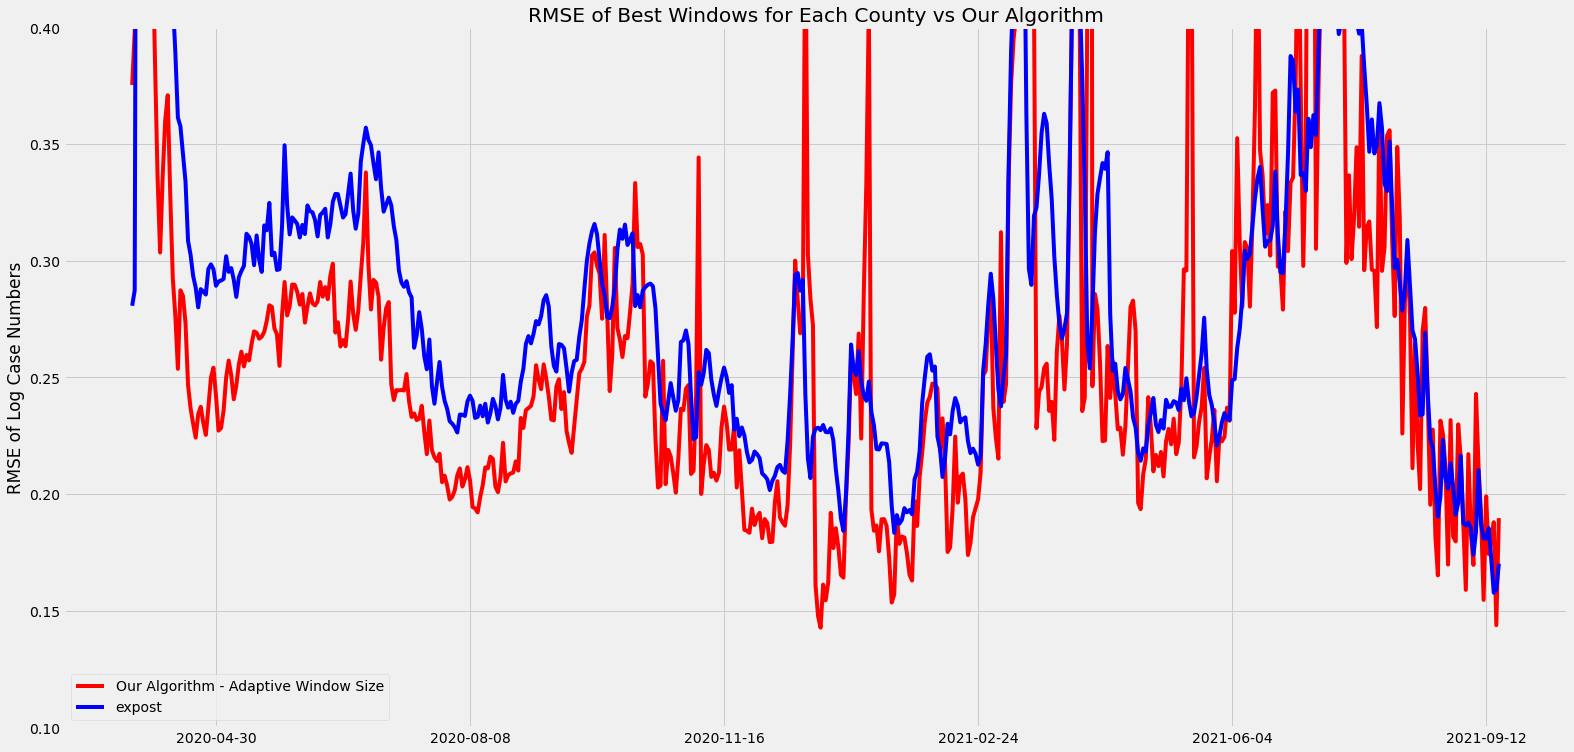

In [32]:
x_spacing = [100,200,300,400,500,600]
fig, ax = plt.subplots(figsize=(24, 12))
#for wsize in range(2,14+1,2):
my_legend = ["expost","Our Algorithm - Adaptive Window Size"]

ax.plot(error_expost_by_day["grf.rmse"], label=my_legend[1], color="red")
ax.plot(error_expost_by_day["lm.rmse"], label=my_legend[0], color="blue")
ax.legend()
plt.xticks(x_spacing,error_expost_by_day["date.y"][x_spacing])
plt.ylim([0.1,0.4])
plt.ylabel("RMSE of Log Case Numbers")
plt.title("RMSE of Best Windows for Each County vs Our Algorithm")
plt.savefig(os.path.join(FIGURES_FOLDER,"best_windows_rmse.png"))

In [33]:
expost_rmse_medians = {}
expost_rmse_medians["grf"] = error_expost_by_day["grf.rmse"].median()
expost_rmse_medians["lm"] = error_expost_by_day["lm.rmse"].median()
expost_rmse_medians

{'grf': 0.24457039886200085, 'lm': 0.26734621959797644}

### limsup of windows per time chosen via cross validation

In [34]:
class GroupTimeSeriesSplit(_BaseKFold):
    """
    Time Series cross-validator for a variable number of observations within the time 
    unit. In the kth split, it returns first k folds as train set and the (k+1)th fold 
    as test set. Indices can be grouped so that they enter the CV fold together.

    Parameters
    ----------
    n_splits : int, default=5
        Number of splits. Must be at least 2.
    max_train_size : int, default=None
        Maximum size for a single training set.
    """
    def __init__(self, n_splits=5, *, max_train_size=None):
        super().__init__(n_splits, shuffle=False, random_state=None)
        self.max_train_size = max_train_size

    def split(self, X, y=None, groups=None):
        """
        Generate indices to split data into training and test set.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            Training data, where n_samples is the number of samples and n_features is 
            the number of features.
        y : array-like of shape (n_samples,)
            Always ignored, exists for compatibility.
        groups : array-like of shape (n_samples,)
            Group labels for the samples used while splitting the dataset into 
            train/test set.
            Most often just a time feature.

        Yields
        -------
        train : ndarray
            The training set indices for that split.
        test : ndarray
            The testing set indices for that split.
        """
        n_splits = self.n_splits
        X, y, groups = indexable(X, y, groups)
        n_samples = _num_samples(X)
        n_folds = n_splits + 1
        indices = np.arange(n_samples)
        group_counts = np.unique(groups, return_counts=True)[1]
        groups = np.split(indices, np.cumsum(group_counts)[:-1])
        n_groups = _num_samples(groups)
        if n_folds > n_groups:
            raise ValueError(
                ("Cannot have number of folds ={0} greater"
                 " than the number of groups: {1}.").format(n_folds, n_groups))
        test_size = (n_groups // n_folds)
        test_starts = range(test_size + n_groups % n_folds,
                            n_groups, test_size)
        for test_start in test_starts:
            if self.max_train_size:
                train_start = np.searchsorted(
                    np.cumsum(
                        group_counts[:test_start][::-1])[::-1] < self.max_train_size + 1, 
                        True)
                yield (np.concatenate(groups[train_start:test_start]),
                       np.concatenate(groups[test_start:test_start + test_size]))
            else:
                yield (np.concatenate(groups[:test_start]),
                       np.concatenate(groups[test_start:test_start + test_size]))


In [35]:
user = np.repeat(np.arange(10), 12)
time = np.tile(pd.date_range(start='2018-01-01', periods=12, freq='M'), 10)
data = (pd.DataFrame({'user': user, 'time': time})
        .sort_values(['time', 'user'])
        .reset_index(drop=True))

In [36]:
ts_data = adjusted[["fips","days_from_start","log_rolled_cases"]].sort_values(["days_from_start","fips"]).reset_index(drop=True)

gtscv = GroupTimeSeriesSplit(n_splits=len(ts_data["days_from_start"].unique())//8+1)
gtscv_gen = gtscv.split(ts_data, groups=ts_data["days_from_start"])
for split_id, (train_id, val_id) in enumerate(gtscv_gen):
    print("Split id: ", split_id, "\n") 
    print("Train id: ", train_id, "\n", "Validation id: ", val_id)
    print("Train dates: ", ts_data.loc[train_id, "days_from_start"].unique(), "\n", "Validation dates: ", ts_data.loc[val_id, "days_from_start"].unique(), "\n")


Split id:  0 

Train id:  [    0     1     2 ... 39298 39299 39300] 
 Validation id:  [39301 39302 39303 ... 47097 47098 47099]
Train dates:  [ 67  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84
  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101 102
 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120
 121 122 123 124 125 126 127 128 129] 
 Validation dates:  [130 131 132 133 134 135 136] 

Split id:  1 

Train id:  [    0     1     2 ... 47097 47098 47099] 
 Validation id:  [47100 47101 47102 ... 55155 55156 55157]
Train dates:  [ 67  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84
  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101 102
 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120
 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136] 
 Validation dates:  [137 138 139 140 141 142 143] 

Split id:  2 

Train id:  [    0     1     2 ... 55155 55156 55157] 

 Validation id:  [248792 248793 248794 ... 264996 264997 264998]
Train dates:  [ 67  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84
  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101 102
 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120
 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138
 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156
 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174
 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192
 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210
 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228
 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246
 247 248] 
 Validation dates:  [249 250 251 252 253 254 255] 

Split id:  18 

Train id:  [     0      1      2 ... 264996 264997 264998] 
 Validation id:  [264999 265000 265001 ... 281734 28

Split id:  25 

Train id:  [     0      1      2 ... 393675 393676 393677] 
 Validation id:  [393678 393679 393680 ... 413920 413921 413922]
Train dates:  [ 67  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84
  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101 102
 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120
 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138
 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156
 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174
 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192
 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210
 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228
 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246
 247 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264
 265 266 267 268 269 270 271 272 273 274 2

Split id:  36 

Train id:  [     0      1      2 ... 621504 621505 621506] 
 Validation id:  [621507 621508 621509 ... 641497 641498 641499]
Train dates:  [ 67  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84
  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101 102
 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120
 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138
 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156
 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174
 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192
 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210
 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228
 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246
 247 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264
 265 266 267 268 269 270 271 272 273 274 2

Train dates:  [ 67  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84
  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101 102
 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120
 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138
 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156
 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174
 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192
 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210
 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228
 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246
 247 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264
 265 266 267 268 269 270 271 272 273 274 275 276 277 278 279 280 281 282
 283 284 285 286 287 288 289 290 291 292 293 294 295 296 297 298 299 300
 301 302 303 304 305 306 307 308 309 

Train dates:  [ 67  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84
  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101 102
 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120
 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138
 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156
 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174
 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192
 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210
 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228
 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246
 247 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264
 265 266 267 268 269 270 271 272 273 274 275 276 277 278 279 280 281 282
 283 284 285 286 287 288 289 290 291 292 293 294 295 296 297 298 299 300
 301 302 303 304 305 306 307 308 309 

Split id:  57 

Train id:  [     0      1      2 ... 950778 950779 950780] 
 Validation id:  [950781 950782 950783 ... 960433 960434 960435]
Train dates:  [ 67  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84
  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101 102
 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120
 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138
 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156
 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174
 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192
 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210
 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228
 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246
 247 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264
 265 266 267 268 269 270 271 272 273 274 2

Split id:  63 

Train id:  [      0       1       2 ... 1024892 1024893 1024894] 
 Validation id:  [1024895 1024896 1024897 ... 1042927 1042928 1042929]
Train dates:  [ 67  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84
  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101 102
 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120
 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138
 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156
 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174
 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192
 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210
 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228
 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246
 247 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264
 265 266 267 268 269 270 271 2

In [67]:
# TCV: For each time, choose lowest average mae across all counties
tcv_rmse = np.zeros(len(adjusted["days_from_start"].unique())-1)
tcv_mae = np.zeros(len(adjusted["days_from_start"].unique())-1)   
tcv_mape = np.zeros(len(adjusted["days_from_start"].unique())-1)                  

counter = 0
for day in sorted(adjusted["days_from_start"].unique())[:-1]:
    day_df = adjusted[adjusted["days_from_start"]==day]
    rmse = np.inf
    mae = np.inf
    mape = np.inf
    rmse_index = 2
    mae_index = 2
    mape_index = 2
    for wsize in range(2,15):
        #rmse = min(rmse,np.sqrt( mean_squared_error( day_df['log_rolled_cases'], day_df['lm.pred.{}'.format(wsize)] )))
        #mae = min(mae,(mean_absolute_error( day_df['log_rolled_cases'], day_df['lm.pred.{}'.format(wsize)] )))
        if rmse > np.sqrt( mean_squared_error( day_df['log_rolled_cases'], day_df['lm.pred.{}'.format(wsize)] )):
            rmse = np.sqrt( mean_squared_error( day_df['log_rolled_cases'], day_df['lm.pred.{}'.format(wsize)] ))
            rmse_index = wsize
        if mae >  mean_absolute_error( day_df['log_rolled_cases'], day_df['lm.pred.{}'.format(wsize)] ):
            mae =  mean_absolute_error( day_df['log_rolled_cases'], day_df['lm.pred.{}'.format(wsize)] )
            mae_index = wsize
        if mape >  mean_absolute_percentage_error( day_df['log_rolled_cases'], day_df['lm.pred.{}'.format(wsize)] ):
            mape =  mean_absolute_percentage_error( day_df['log_rolled_cases'], day_df['lm.pred.{}'.format(wsize)] )
            mape_index = wsize
    day_df_future = adjusted[adjusted["days_from_start"]==day+1]
    
    rmse_future = np.sqrt( mean_squared_error( day_df_future['log_rolled_cases'], day_df_future['lm.pred.{}'.format(rmse_index)] ))
    mae_future = mean_absolute_error( day_df_future['log_rolled_cases'], day_df_future['lm.pred.{}'.format(mae_index)] )
    mape_future = mean_absolute_percentage_error( day_df_future['log_rolled_cases'], day_df_future['lm.pred.{}'.format(mape_index)] )

    tcv_rmse[counter] = rmse_future
    tcv_mae[counter] = mae_future
    tcv_mape[counter] = mape_future
    counter += 1
                   

In [68]:
tcv_mae = pd.DataFrame(tcv_mae)
tcv_mae.index = sorted(adjusted["days_from_start"].unique())[1:]
tcv_rmse = pd.DataFrame(tcv_rmse)
tcv_rmse.index = sorted(adjusted["days_from_start"].unique())[1:]
tcv_mape = pd.DataFrame(tcv_mape)
tcv_mape.index = sorted(adjusted["days_from_start"].unique())[1:]


In [69]:
tcv_mae

,0
68,0.235071
69,0.462440
70,0.402215
71,0.344680
72,0.458895
...,...
601,0.135046
602,0.124304
603,0.112471
604,0.114513


In [70]:
#error_table[mape_columns]
#error_table[rmse_columns]
lm_mape_columns = ["lm.mape.{}".format(wsize) for wsize in range(2,14+1)]
lm_rmse_columns = ["lm.rmse.{}".format(wsize) for wsize in range(2,14+1)]

limsup_mape = error_table[lm_mape_columns].max(axis=1)
limsup_rmse = error_table[lm_rmse_columns].max(axis=1)

In [71]:
limsup_mape

days_from_start
67     0.063725
68     0.051830
69     0.071155
70     0.077730
71     0.084494
         ...   
601    0.027954
602    0.026439
603    0.026288
604    0.024311
605    0.029514
Length: 539, dtype: float64

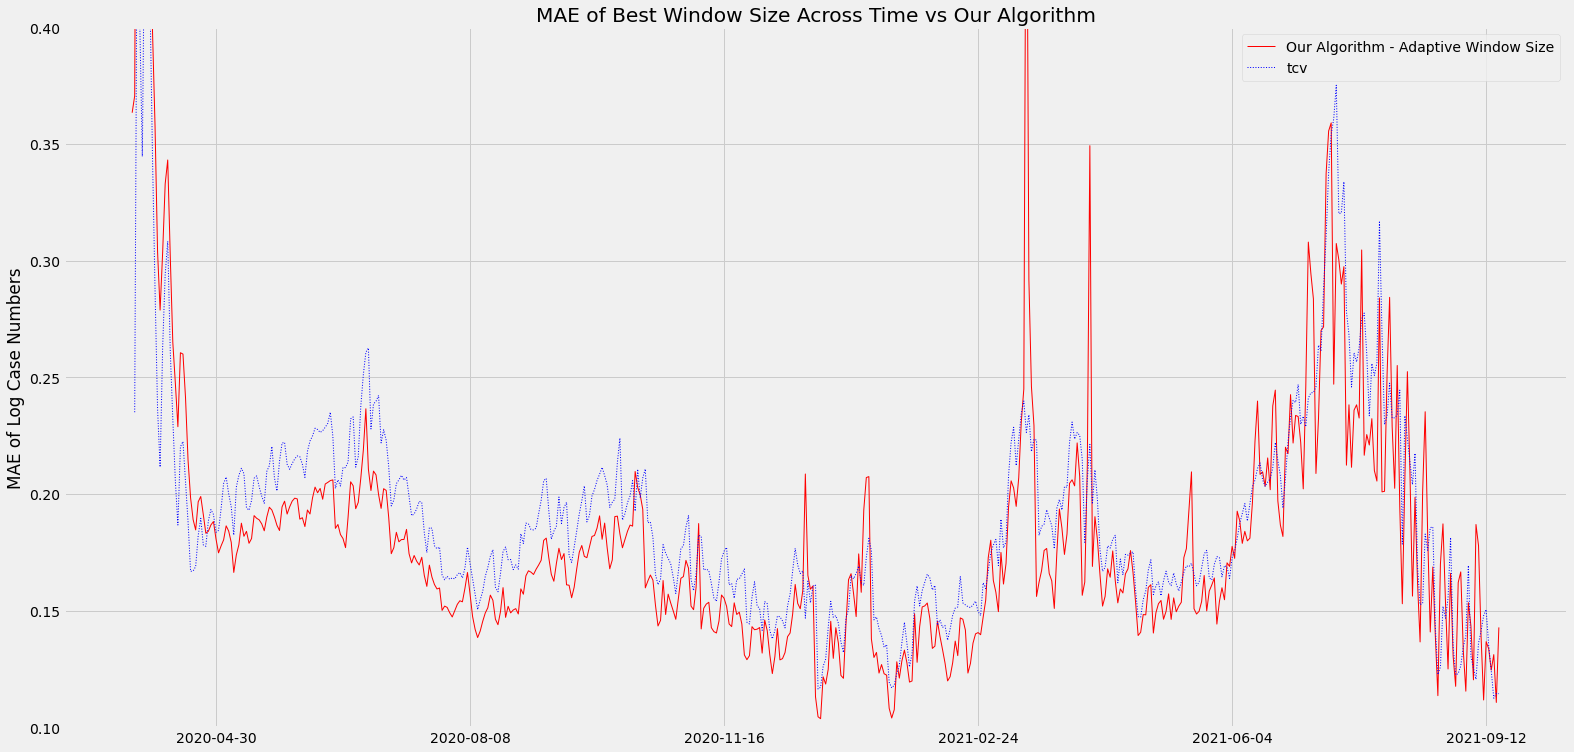

In [72]:
x_spacing = [100,200,300,400,500,600]
fig, ax = plt.subplots(figsize=(24, 12))
#for wsize in range(2,14+1,2):
ax.plot(error_table["grf.mae"], label="Our Algorithm - Adaptive Window Size", color="red", linewidth=1)
ax.plot(tcv_mae, label="tcv", color="blue", linestyle='dotted', linewidth=1)
ax.legend()
plt.xticks(x_spacing,error_table["date"][x_spacing])
plt.ylim([0.1,0.4])
plt.ylabel("MAE of Log Case Numbers")
plt.title("MAE of Best Window Size Across Time vs Our Algorithm")
plt.savefig(os.path.join(FIGURES_FOLDER,"limsup_mae.png"))

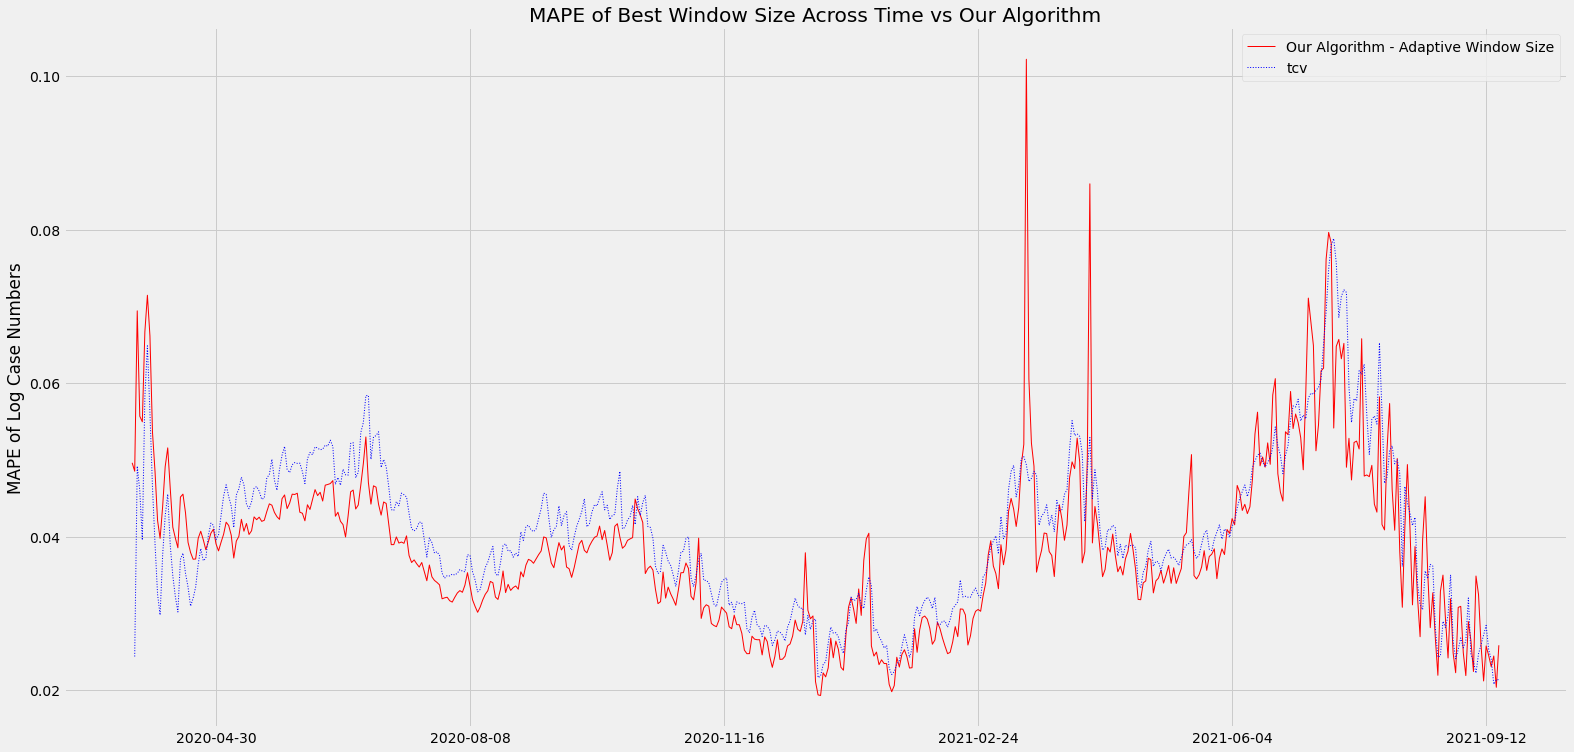

In [73]:
x_spacing = [100,200,300,400,500,600]
fig, ax = plt.subplots(figsize=(24, 12))
#for wsize in range(2,14+1,2):
ax.plot(error_table["grf.mape"], label="Our Algorithm - Adaptive Window Size", color="red", linewidth=1)
ax.plot(tcv_mape, label="tcv", color="blue", linestyle='dotted', linewidth=1)
ax.legend()
plt.xticks(x_spacing,error_table["date"][x_spacing])
#plt.ylim([0.1,0.4])
plt.ylabel("MAPE of Log Case Numbers")
plt.title("MAPE of Best Window Size Across Time vs Our Algorithm")
plt.savefig(os.path.join(FIGURES_FOLDER,"limsup_mape.png"))

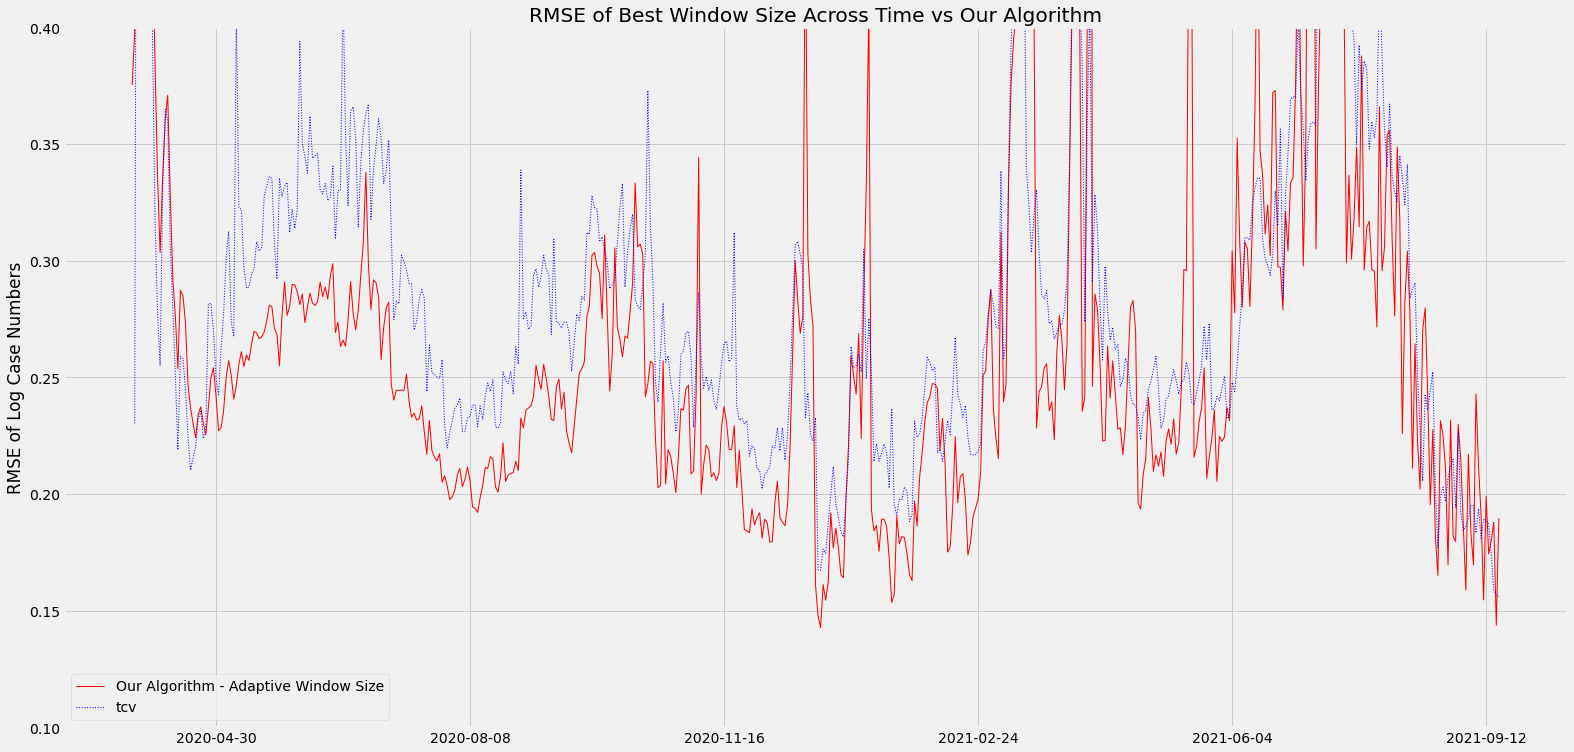

In [74]:
x_spacing = [100,200,300,400,500,600]
fig, ax = plt.subplots(figsize=(24, 12))
#for wsize in range(2,14+1,2):
ax.plot(error_table["grf.rmse"], label="Our Algorithm - Adaptive Window Size", color="red", linewidth=1)
ax.plot(tcv_rmse, label="tcv", color="blue", linestyle='dotted', linewidth=1)
ax.legend()
plt.xticks(x_spacing,error_table["date"][x_spacing])
plt.ylim([0.1,0.4])
plt.ylabel("RMSE of Log Case Numbers")
plt.title("RMSE of Best Window Size Across Time vs Our Algorithm")
#plt.xlim([365,len(grf_rmse)])
plt.savefig(os.path.join(FIGURES_FOLDER,"limsup_rmse.png"))

In [77]:
tcv_mae_medians = {}
tcv_mae_medians["grf"] = error_expost_by_day["grf.mae"].median()
tcv_mae_medians["lm"] = tcv_mae.median()
tcv_mae_medians

{'grf': 0.16957942431221626,
 'lm': 0    0.182276
 dtype: float64}

In [79]:
tcv_mape_medians = {}
tcv_mape_medians["grf"] = error_expost_by_day["grf.mape"].median()
tcv_mape_medians["lm"] = tcv_mape.median()
tcv_mape_medians

{'grf': 0.03764665794955454,
 'lm': 0    0.039705
 dtype: float64}

In [78]:
tcv_rmse_medians = {}
tcv_rmse_medians["grf"] = error_expost_by_day["grf.rmse"].median()
tcv_rmse_medians["lm"] = tcv_rmse.median()
tcv_rmse_medians

{'grf': 0.24457039886200085,
 'lm': 0    0.270491
 dtype: float64}

### liminf of windows per time chosen via cross validation

In [46]:
#error_table[mape_columns]
#error_table[rmse_columns]
lm_mape_columns = ["lm.mape.{}".format(wsize) for wsize in range(2,14+1)]
lm_rmse_columns = ["lm.rmse.{}".format(wsize) for wsize in range(2,14+1)]

liminf_mape = error_table[lm_mape_columns].min(axis=1)
liminf_rmse = error_table[lm_rmse_columns].min(axis=1)

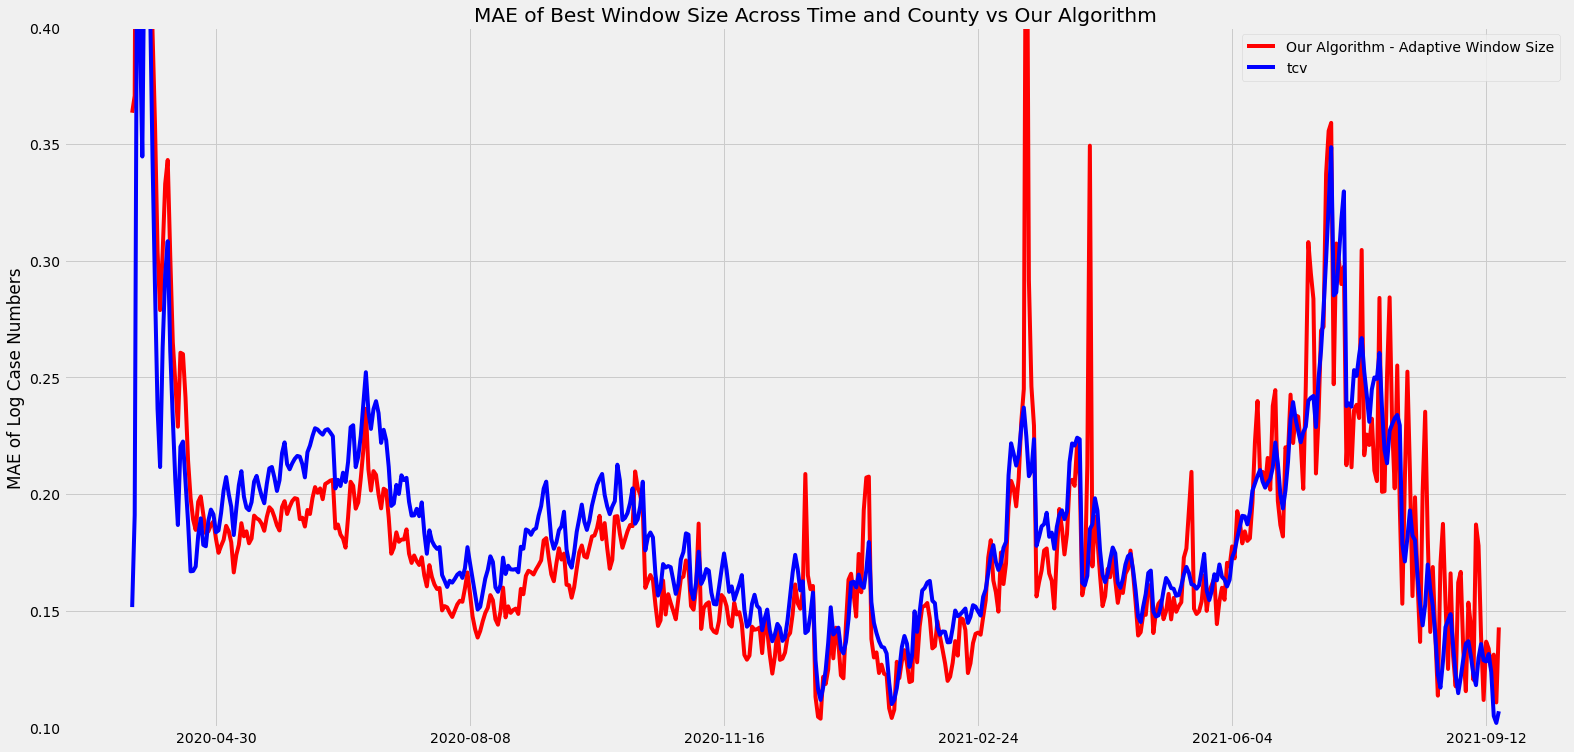

In [47]:
x_spacing = [100,200,300,400,500,600]
fig, ax = plt.subplots(figsize=(24, 12))
#for wsize in range(2,14+1,2):
ax.plot(error_table["grf.mape"], label="Our Algorithm - Adaptive Window Size", color="red")
ax.plot(liminf_mape, label="tcv", color="blue")
ax.legend()
plt.xticks(x_spacing,error_table["date"][x_spacing])
plt.ylim([0.1,0.4])
plt.ylabel("MAE of Log Case Numbers")
plt.title("MAE of Best Window Size Across Time and County vs Our Algorithm")
plt.savefig(os.path.join(FIGURES_FOLDER,"liminf_mae.png"))

In [48]:
tcv_mae_medians = {}
tcv_mae_medians["grf"] = error_expost_by_day["grf.mape"].median()
tcv_mae_medians["lm"] = liminf_mape.median()
tcv_mae_medians

{'grf': 0.16957942431221626, 'lm': 0.17721658008491134}

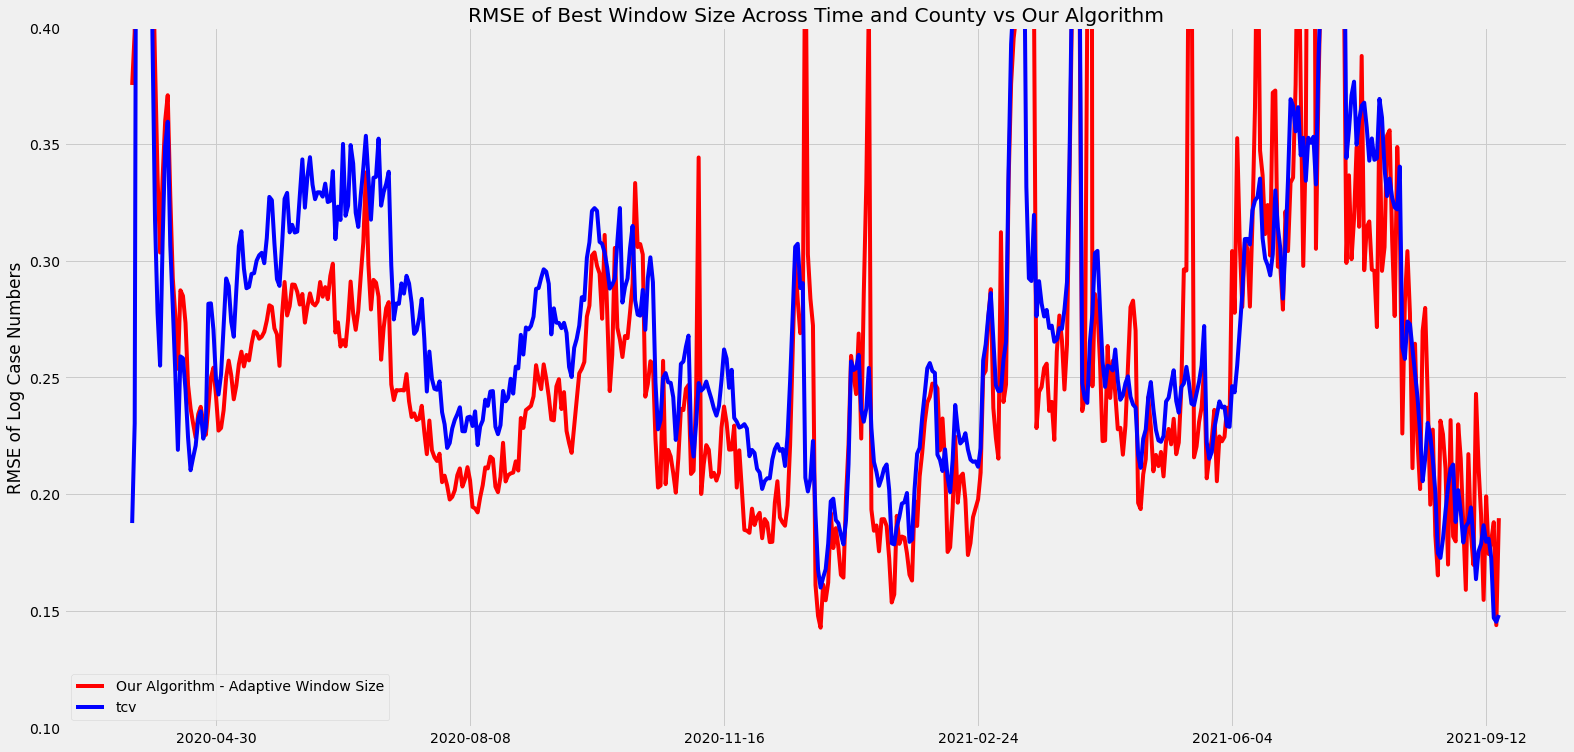

In [49]:
x_spacing = [100,200,300,400,500,600]
fig, ax = plt.subplots(figsize=(24, 12))
#for wsize in range(2,14+1,2):
ax.plot(error_table["grf.rmse"], label="Our Algorithm - Adaptive Window Size", color="red")
ax.plot(liminf_rmse, label="tcv", color="blue")
ax.legend()
plt.xticks(x_spacing,error_table["date"][x_spacing])
plt.ylim([0.1,0.4])
plt.ylabel("RMSE of Log Case Numbers")
plt.title("RMSE of Best Window Size Across Time and County vs Our Algorithm")
#plt.xlim([365,len(grf_rmse)])
plt.savefig(os.path.join(FIGURES_FOLDER,"liminf_rmse.png"))

In [50]:
tcv_rmse_medians = {}
tcv_rmse_medians["grf"] = error_expost_by_day["grf.rmse"].median()
tcv_rmse_medians["lm"] = liminf_rmse.median()
tcv_rmse_medians

{'grf': 0.24457039886200085, 'lm': 0.25805646749498695}

In [51]:
dict(sorted(collections.Counter(fips_rmse.values()).items(), key=lambda e:e[0]))

{2: 791,
 3: 561,
 4: 87,
 5: 51,
 6: 116,
 7: 188,
 8: 242,
 9: 195,
 10: 117,
 11: 79,
 12: 58,
 13: 83,
 14: 533}

In [52]:
adjusted

,fips,days_from_start,predicted.grf,date,county,state,log_rolled_cases,lm.pred.2,lm.pred.3,lm.pred.4,lm.pred.5,lm.pred.6,lm.pred.7,lm.pred.8,lm.pred.9,lm.pred.10,lm.pred.11,lm.pred.12,lm.pred.13,lm.pred.14
20,10001,88,6.233389,2020-04-18,Kent,Delaware,5.881929,6.274697,6.305973,6.460198,6.657827,6.779492,6.894292,6.933171,6.933535,6.915480,6.879093,6.837612,6.794018,6.743927
21,10001,89,6.066028,2020-04-19,Kent,Delaware,5.920908,6.051755,6.203723,6.283276,6.420656,6.596258,6.723148,6.842956,6.900525,6.921485,6.921946,6.902623,6.875277,6.843273
22,10001,90,6.082748,2020-04-20,Kent,Delaware,5.964864,6.061046,6.092416,6.196145,6.275717,6.396586,6.552313,6.676777,6.796304,6.864985,6.900380,6.915099,6.909804,6.894752
23,10001,91,6.204923,2020-04-21,Kent,Delaware,6.006969,6.251632,6.199764,6.197839,6.260801,6.323979,6.424278,6.558545,6.674240,6.788287,6.861333,6.905206,6.929540,6.934606
24,10001,92,6.200526,2020-04-22,Kent,Delaware,6.050912,6.217303,6.270319,6.260405,6.262809,6.309705,6.362789,6.448108,6.565097,6.671602,6.779032,6.853294,6.902291,6.933330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1526331,99999,601,10.590581,2021-09-13,New York City,New York,10.557114,10.552786,10.503129,10.484691,10.504834,10.534865,10.564571,10.586209,10.599192,10.606162,10.613438,10.620428,10.626583,10.631276
1526332,99999,602,10.543993,2021-09-14,New York City,New York,10.551304,10.500115,10.518746,10.496403,10.481217,10.492194,10.514025,10.538337,10.557812,10.570795,10.578768,10.586769,10.594369,10.601123
1526333,99999,603,10.543655,2021-09-15,New York City,New York,10.535902,10.511698,10.499888,10.506343,10.491571,10.478665,10.484527,10.500536,10.520276,10.537306,10.549537,10.557702,10.565850,10.573621
1526334,99999,604,10.530825,2021-09-16,New York City,New York,10.546380,10.493169,10.496010,10.490061,10.493357,10.482845,10.472136,10.475291,10.487376,10.503584,10.518416,10.529695,10.537693,10.545709


In [53]:
class WindowedTestTimeSeriesSplit(TimeSeriesSplit):
    """
    parameters
    ----------
    n_test_folds: int
        number of folds to be used as testing at each iteration.
        by default, 1.
    """
    @_deprecate_positional_args
    def __init__(self, n_splits=5, *, max_train_size=None, n_test_folds=1):
        super().__init__(n_splits, 
                         max_train_size=max_train_size)
        self.n_test_folds=n_test_folds

    def split(self, X, y=None, groups=None):
        """Generate indices to split data into training and test set.
        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            Training data, where n_samples is the number of samples
            and n_features is the number of features.
        y : array-like of shape (n_samples,)
            Always ignored, exists for compatibility.
        groups : array-like of shape (n_samples,)
            Always ignored, exists for compatibility.
        Yields
        ------
        train : ndarray
            The training set indices for that split.
        test : ndarray
            The testing set indices for that split.
        """
        X, y, groups = indexable(X, y, groups)
        n_samples = _num_samples(X)
        n_splits = self.n_splits
        n_folds = n_splits + self.n_test_folds
        if n_folds > n_samples:
            raise ValueError(
                ("Cannot have number of folds ={0} greater"
                 " than the number of samples: {1}.").format(n_folds,
                                                             n_samples))
        indices = np.arange(n_samples)
        fold_size = (n_samples // n_folds)
        test_size = fold_size * self.n_test_folds # test window
        test_starts = range(fold_size + n_samples % n_folds,
                            n_samples-test_size+1, fold_size) # splits based on fold_size instead of test_size
        for test_start in test_starts:
            if self.max_train_size and self.max_train_size < test_start:
                yield (indices[test_start - self.max_train_size:test_start],
                       indices[test_start:test_start + test_size])
            else:
                yield (indices[:test_start],
                       indices[test_start:test_start + test_size])
